In [1]:
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

In [83]:
data_path = "/home/riccardo/Documents/orbit/source/standalone/logs/rsl_rl/unitree_go1_jump/"

In [84]:
# results = data_path +"_test.bin"
results = data_path +"test.bin"

In [85]:
data = joblib.load(results)

In [86]:
data

array([[[ 0.22402954,  0.21755981,  0.40000004],
        [-0.48260498, -0.02597046,  0.40000004],
        [ 0.40821838,  0.26452637,  0.40000004],
        ...,
        [ 0.7121582 , -0.00921631,  0.40000004],
        [-0.20858765,  0.19889832,  0.40000004],
        [ 0.77008057,  0.18745422,  0.40000004]],

       [[ 0.24893188,  0.18411255,  0.39999214],
        [-0.45892334, -0.02033997,  0.4000009 ],
        [ 0.39346313,  0.23545837,  0.3998495 ],
        ...,
        [ 0.65419006, -0.02111816,  0.4000051 ],
        [-0.21855164,  0.15596008,  0.40000436],
        [ 0.6207733 ,  0.0945282 ,  0.3999978 ]]], dtype=float32)

In [87]:
data.shape

(2, 10000, 3)

In [88]:
des = data[0][:,:2]
des

array([[ 0.22402954,  0.21755981],
       [-0.48260498, -0.02597046],
       [ 0.40821838,  0.26452637],
       ...,
       [ 0.7121582 , -0.00921631],
       [-0.20858765,  0.19889832],
       [ 0.77008057,  0.18745422]], dtype=float32)

In [89]:
actual = data[1][:,:2]
actual

array([[ 0.24893188,  0.18411255],
       [-0.45892334, -0.02033997],
       [ 0.39346313,  0.23545837],
       ...,
       [ 0.65419006, -0.02111816],
       [-0.21855164,  0.15596008],
       [ 0.6207733 ,  0.0945282 ]], dtype=float32)

In [90]:
err = np.linalg.norm(data[0][:,:2] - data[1][:,:2], axis=1)
err

array([0.04169948, 0.02434179, 0.03259855, ..., 0.05917735, 0.04407917,
       0.1758633 ], dtype=float32)

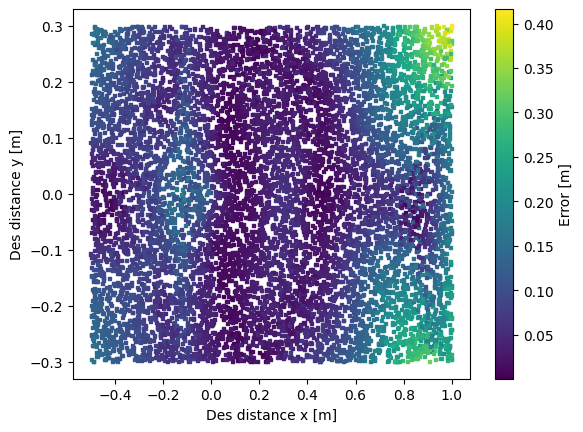

In [91]:
plt.scatter(des[:,0],des[:,1], np.full(des[: , 1].shape,5), marker='s', c=err)
plt.colorbar(label="Error [m]")
plt.xlabel("Des distance x [m]")
plt.ylabel("Des distance y [m]")
plt.savefig(data_path+"abs_err.pdf")
plt.show()

In [92]:
#  try to interpolate data
grid_x, grid_y = np.mgrid[des[:,0].min():des[:,0].max():100j, des[:,1].min():des[:,1].max():100j]

In [37]:
from scipy.ndimage import gaussian_filter

In [93]:
grid_z = griddata(des, err, (grid_x, grid_y), method='linear')
# grid_z = gaussian_filter(grid_z, sigma=1)

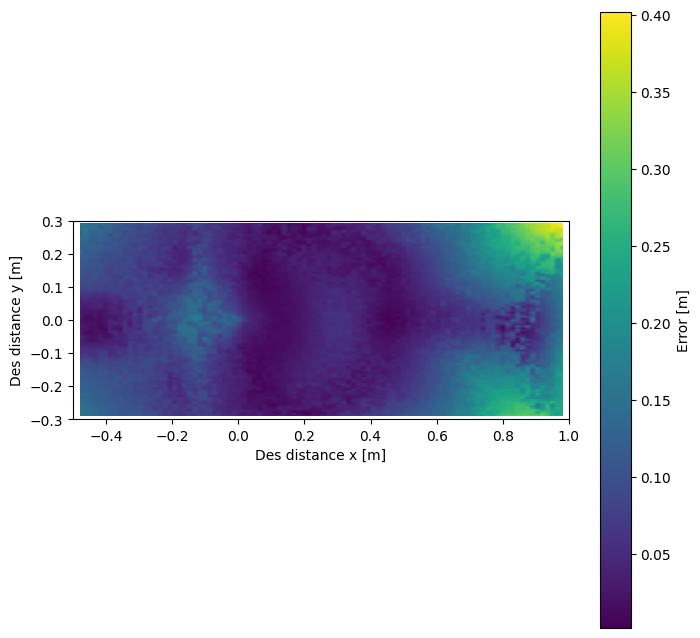

In [96]:
plt.figure(figsize=(8, 8))
plt.imshow(grid_z.T, extent=(-.5,1,-.3,.3), origin='lower')
# plt.imshow(grid_z.T, extent=(0,1,-.3,.3), origin='lower')
plt.colorbar(label="Error [m]")
plt.xlabel("Des distance x [m]")
plt.ylabel("Des distance y [m]")
plt.savefig(data_path+"abs_err_interpolated.pdf")
plt.show()

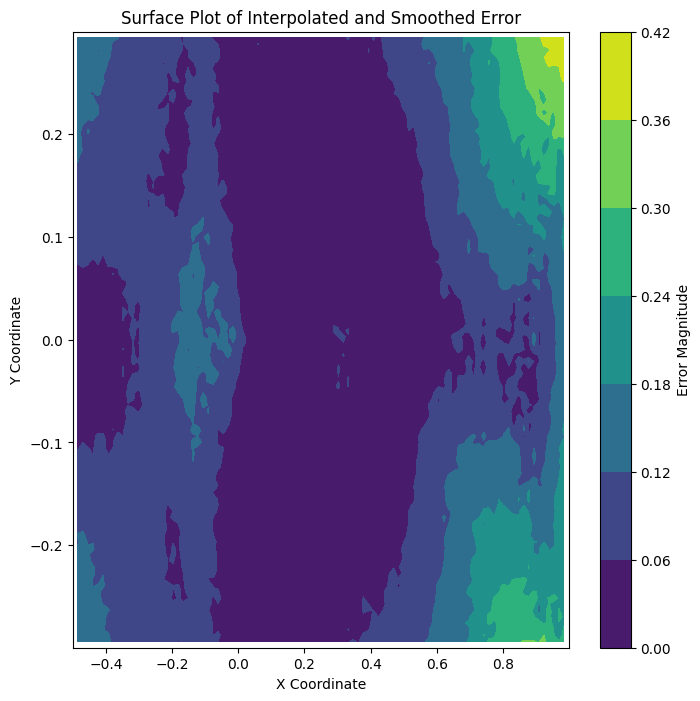

In [97]:
plt.figure(figsize=(8, 8))
plt.contourf(grid_x, grid_y, grid_z, cmap='viridis')
plt.colorbar(label='Error Magnitude')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Surface Plot of Interpolated and Smoothed Error')
plt.show()

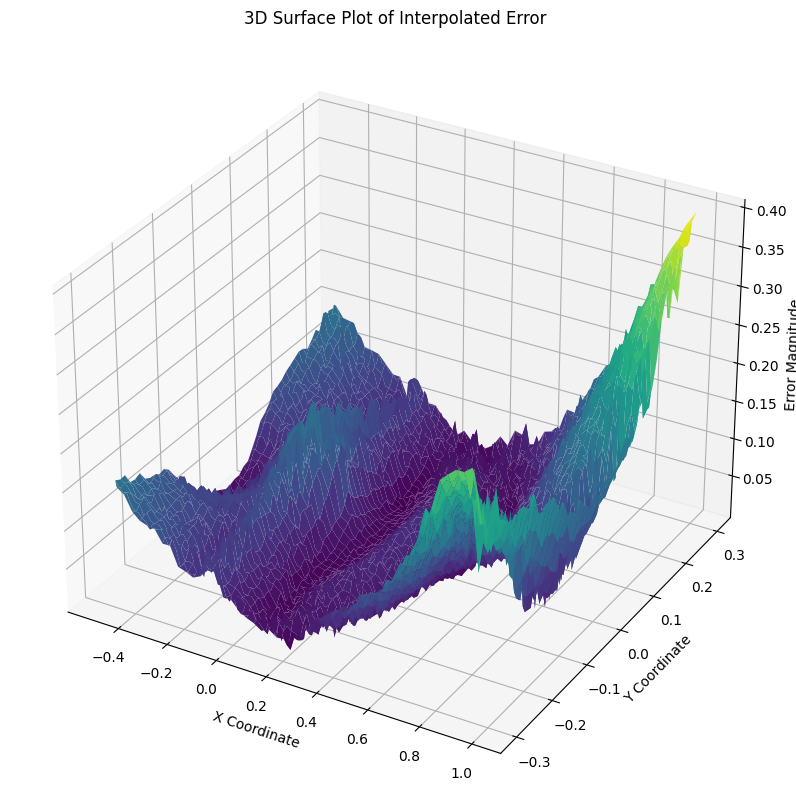

In [106]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(grid_x, grid_y, grid_z, cmap='viridis')
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
# plt.colorbar(label="Error [m]")
ax.set_zlabel('Error Magnitude')
ax.set_title('3D Surface Plot of Interpolated Error')
plt.show()


In [99]:
des_dist = np.linalg.norm(des, axis=1)
des_dist

array([0.31228435, 0.48330325, 0.48643237, ..., 0.7122178 , 0.28821754,
       0.79256743], dtype=float32)

In [100]:
actual_dist = np.linalg.norm(actual, axis=1)
actual_dist

array([0.30961993, 0.45937386, 0.4585345 , ..., 0.6545308 , 0.26849276,
       0.6279292 ], dtype=float32)

In [101]:
np.linalg.norm([0.6,.3])

0.6708203932499369

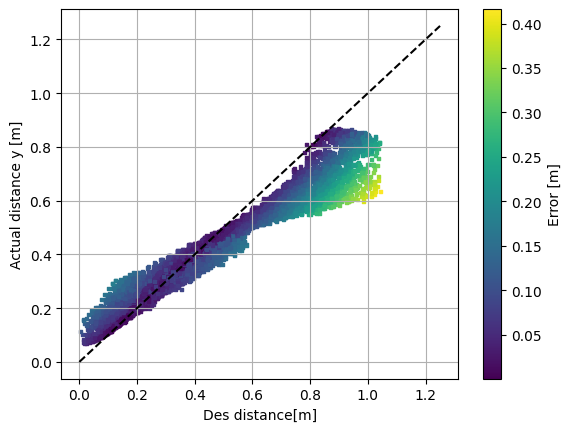

In [102]:
plt.grid()
plt.scatter(des_dist,actual_dist, np.full(des[: , 1].shape,5), marker='s', c=err, alpha=1)
plt.plot([0.0,1.25],[0.0,1.25], '--', color="black")
plt.colorbar(label="Error [m]")
plt.xlabel("Des distance[m]")
plt.ylabel("Actual distance y [m]")
plt.savefig(data_path+"diag_err.pdf")
plt.show()

In [103]:
perc_err = err / des_dist
perc_err

array([0.13353047, 0.05036545, 0.06701559, ..., 0.08308885, 0.15293713,
       0.22189064], dtype=float32)

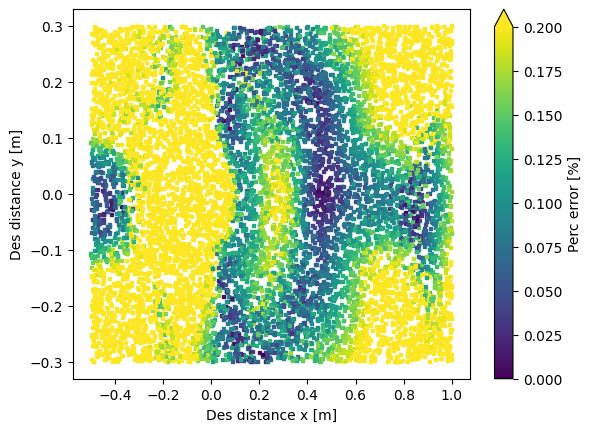

In [104]:
plt.scatter(des[:,0],des[:,1], np.full(des[: , 1].shape,5), marker='s', c=perc_err, vmin=0, vmax=.2)
plt.colorbar(label="Perc error [%]", extend='max')
plt.xlabel("Des distance x [m]")
plt.ylabel("Des distance y [m]")
plt.savefig(data_path+"perc_err.pdf")
plt.show()

In [107]:
data_path = "/home/riccardo/Documents/orbit/source/standalone/logs/rsl_rl/unitree_a1_jump/"

In [108]:
# results = data_path +"_test.bin"
results = data_path +"test.bin"

In [109]:
data = joblib.load(results)

In [110]:
data

array([[[ 0.17318726, -0.12640381,  0.40000004],
        [ 0.39556885,  0.09158325,  0.40000004],
        [-0.31929016,  0.05949402,  0.40000004],
        ...,
        [ 0.40124512, -0.19502258,  0.40000004],
        [-0.24403381, -0.23704529,  0.40000004],
        [ 0.8427124 , -0.29644775,  0.40000004]],

       [[ 0.18431091, -0.09608459,  0.40025225],
        [ 0.44140625,  0.06874084,  0.40041834],
        [-0.3380432 ,  0.04362488,  0.40927562],
        ...,
        [ 0.43406677, -0.14778137,  0.400027  ],
        [-0.26281738, -0.15945435,  0.40672162],
        [ 0.34240723, -0.08609009,  0.4000515 ]]], dtype=float32)

In [111]:
data.shape

(2, 10000, 3)

In [112]:
des = data[0][:,:2]
des

array([[ 0.17318726, -0.12640381],
       [ 0.39556885,  0.09158325],
       [-0.31929016,  0.05949402],
       ...,
       [ 0.40124512, -0.19502258],
       [-0.24403381, -0.23704529],
       [ 0.8427124 , -0.29644775]], dtype=float32)

In [113]:
actual = data[1][:,:2]
actual

array([[ 0.18431091, -0.09608459],
       [ 0.44140625,  0.06874084],
       [-0.3380432 ,  0.04362488],
       ...,
       [ 0.43406677, -0.14778137],
       [-0.26281738, -0.15945435],
       [ 0.34240723, -0.08609009]], dtype=float32)

In [114]:
err = np.linalg.norm(data[0][:,:2] - data[1][:,:2], axis=1)
err

array([0.03229536, 0.0512137 , 0.02456637, ..., 0.05752385, 0.07983217,
       0.5427298 ], dtype=float32)

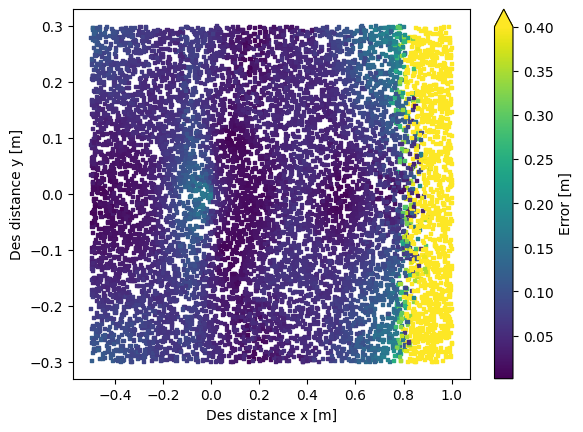

In [118]:
plt.scatter(des[:,0],des[:,1], np.full(des[: , 1].shape,5), marker='s', c=err, vmax=0.4)
plt.colorbar(label="Error [m]", extend="max")
plt.xlabel("Des distance x [m]")
plt.ylabel("Des distance y [m]")
plt.savefig(data_path+"abs_err.pdf")
plt.show()

In [119]:
#  try to interpolate data
grid_x, grid_y = np.mgrid[des[:,0].min():des[:,0].max():100j, des[:,1].min():des[:,1].max():100j]

In [120]:
from scipy.ndimage import gaussian_filter

In [121]:
grid_z = griddata(des, err, (grid_x, grid_y), method='linear')
# grid_z = gaussian_filter(grid_z, sigma=1)

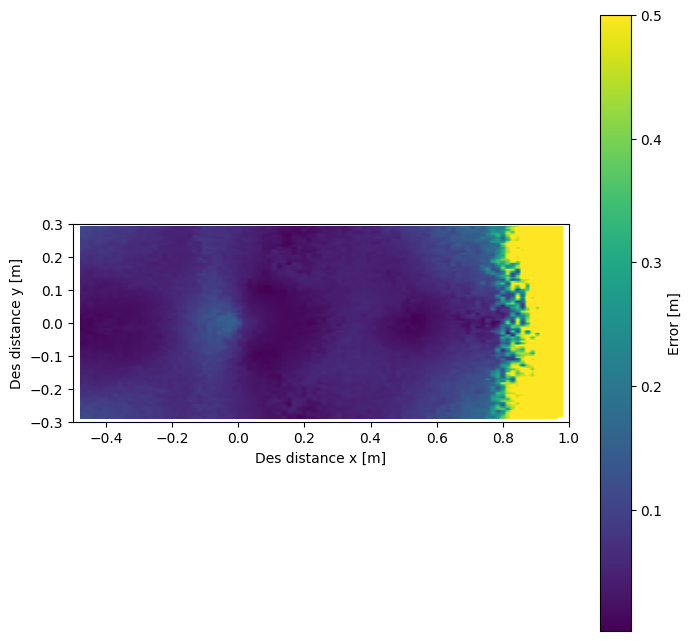

In [124]:
plt.figure(figsize=(8, 8))
plt.imshow(grid_z.T, extent=(-.5,1,-.3,.3), origin='lower', vmax=0.5)
# plt.imshow(grid_z.T, extent=(0,1,-.3,.3), origin='lower')
plt.colorbar(label="Error [m]")
plt.xlabel("Des distance x [m]")
plt.ylabel("Des distance y [m]")
plt.savefig(data_path+"abs_err_interpolated.pdf")
plt.show()

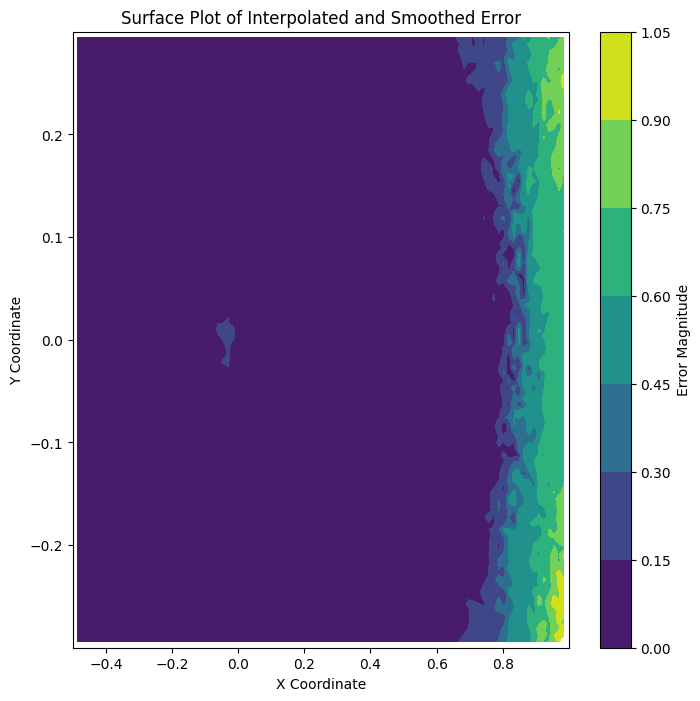

In [125]:
plt.figure(figsize=(8, 8))
plt.contourf(grid_x, grid_y, grid_z, cmap='viridis')
plt.colorbar(label='Error Magnitude')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Surface Plot of Interpolated and Smoothed Error')
plt.show()

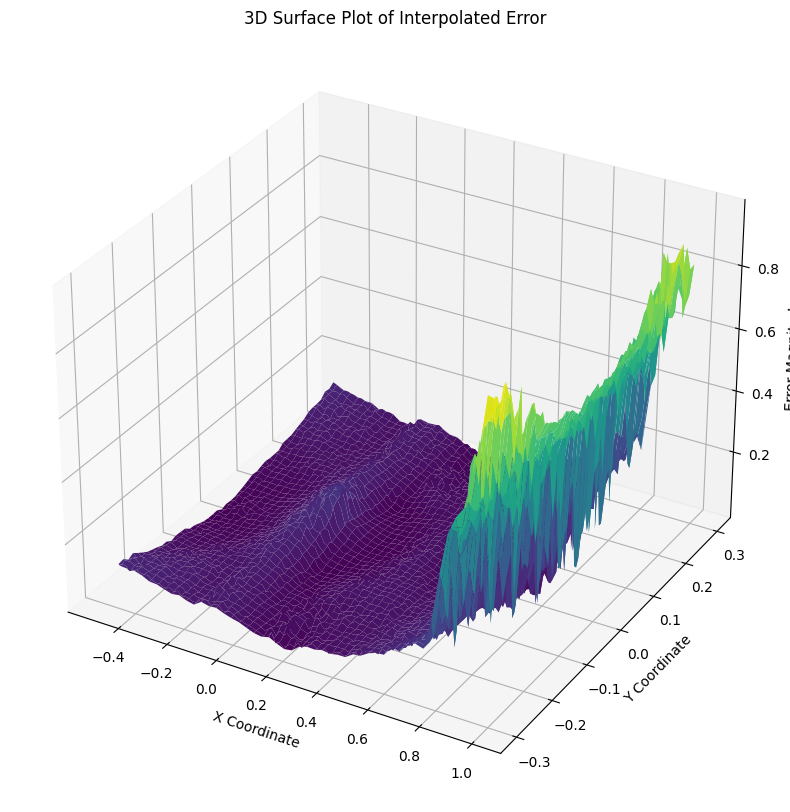

In [126]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(grid_x, grid_y, grid_z, cmap='viridis')
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
# plt.colorbar(label="Error [m]")
ax.set_zlabel('Error Magnitude')
ax.set_title('3D Surface Plot of Interpolated Error')
plt.show()


In [127]:
des_dist = np.linalg.norm(des, axis=1)
des_dist

array([0.21441023, 0.40603226, 0.32478568, ..., 0.4461294 , 0.34021017,
       0.8933339 ], dtype=float32)

In [128]:
actual_dist = np.linalg.norm(actual, axis=1)
actual_dist

array([0.20785274, 0.44672674, 0.3408465 , ..., 0.45853385, 0.30740634,
       0.35306403], dtype=float32)

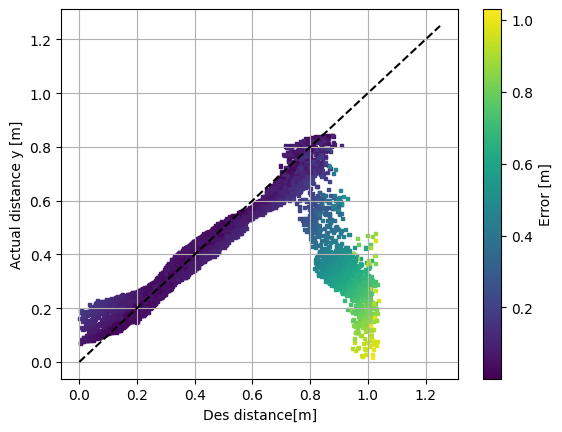

In [130]:
plt.grid()
plt.scatter(des_dist,actual_dist, np.full(des[: , 1].shape,5), marker='s', c=err, alpha=1)
plt.plot([0.0,1.25],[0.0,1.25], '--', color="black")
plt.colorbar(label="Error [m]")
plt.xlabel("Des distance[m]")
plt.ylabel("Actual distance y [m]")
plt.savefig(data_path+"diag_err.pdf")
plt.show()

In [131]:
perc_err = err / des_dist
perc_err

array([0.15062419, 0.1261321 , 0.07563871, ..., 0.12893982, 0.23465545,
       0.607533  ], dtype=float32)

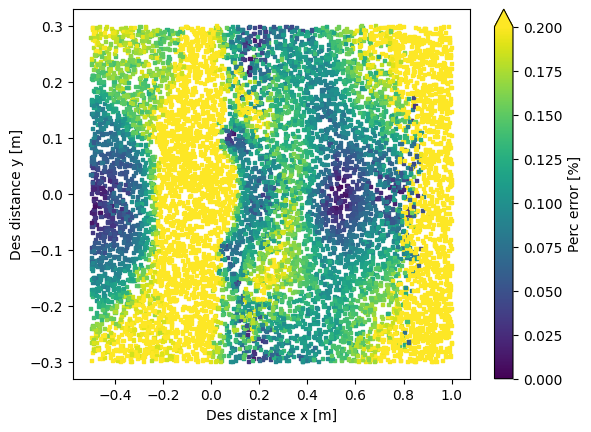

In [132]:
plt.scatter(des[:,0],des[:,1], np.full(des[: , 1].shape,5), marker='s', c=perc_err, vmin=0, vmax=.2)
plt.colorbar(label="Perc error [%]", extend='max')
plt.xlabel("Des distance x [m]")
plt.ylabel("Des distance y [m]")
plt.savefig(data_path+"perc_err.pdf")
plt.show()